In [8]:
!git clone https://github.com/macaspe4/aprendizaje_profundo.git

import sys
import os
sys.path.append('/content/aprendizaje_profundo')

from modelos.modelos_simples import crear_red_simple

fatal: destination path 'aprendizaje_profundo' already exists and is not an empty directory.


In [9]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import accuracy_score, f1_score
import matplotlib.pyplot as plt


df = pd.read_csv('wfh_burnout_dataset.csv')

features = ['work_hours', 'screen_time_hours', 'meetings_count', 'breaks_taken',
            'after_hours_work', 'app_switches', 'sleep_hours', 'task_completion',
            'isolation_index', 'fatigue_score']
X = df[features]
y = LabelEncoder().fit_transform(df['burnout_risk'])

# Primera división: 70% train, 30% temp
X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.30, random_state=42, stratify=y)

# Segunda división: del 30% temp, mitad para val y mitad para test
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.50, random_state=42, stratify=y_temp)

scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_val_sc = scaler.transform(X_val)
X_test_sc = scaler.transform(X_test)

print(f"Dimensiones: Train {X_train_sc.shape}, Val {X_val_sc.shape}, Test {X_test_sc.shape}")

Dimensiones: Train (1400, 10), Val (300, 10), Test (300, 10)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_1 (Dense)                 │ (None, 3)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 33 (132.00 B)

 Trainable params: 33 (132.00 B)

 Non-trainable params: 0 (0.00 B)

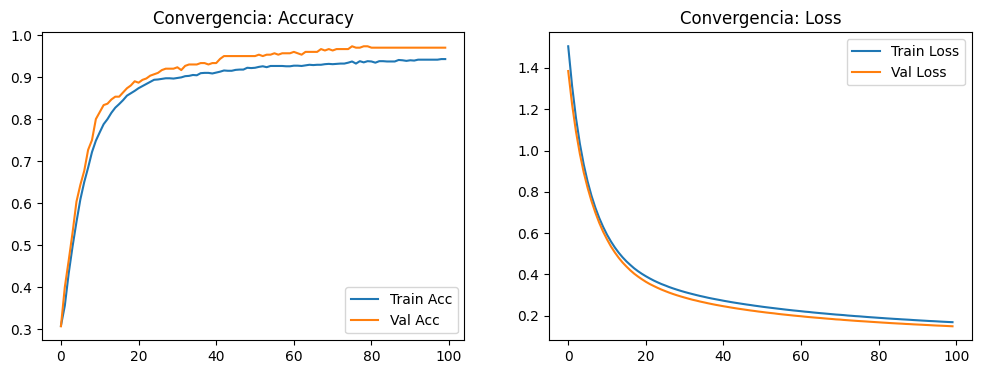

In [10]:
modelo_nn = crear_red_simple(input_shape=X_train_sc.shape[1])

modelo_nn.summary()

history = modelo_nn.fit(
    X_train_sc, y_train,
    validation_data=(X_val_sc, y_val),
    epochs=100,
    verbose=0
)

plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train Acc')
plt.plot(history.history['val_accuracy'], label='Val Acc')
plt.title('Convergencia: Accuracy')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.title('Convergencia: Loss')
plt.legend()

plt.show()

In [11]:
y_train_pred = np.argmax(modelo_nn.predict(X_train_sc), axis=1)
y_val_pred = np.argmax(modelo_nn.predict(X_val_sc), axis=1)
y_test_pred = np.argmax(modelo_nn.predict(X_test_sc), axis=1)

train_acc = accuracy_score(y_train, y_train_pred)
val_acc = accuracy_score(y_val, y_val_pred)
test_acc = accuracy_score(y_test, y_test_pred)
test_f1 = f1_score(y_test, y_test_pred, average='macro')

print("MÉTRICAS FINALES")
print(f"Train Accuracy: {train_acc:.4f}")
print(f"Val Accuracy:   {val_acc:.4f}")
print(f"Test Accuracy:  {test_acc:.4f}")
print(f"Test F1 (Macro): {test_f1:.4f}")

44/44 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step 
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step 
MÉTRICAS FINALES
Train Accuracy: 0.9421
Val Accuracy:   0.9700
Test Accuracy:  0.9367
Test F1 (Macro): 0.8243


### Conclusión de los resultados
La red neuronal (Perceptrón) que se implementó en un archivo externo .py ha funcionado correctamente y ha logrado aprender bien a partir de los datos. En las gráficas de entrenamiento se puede ver que tanto la pérdida como la precisión se estabilizan rápidamente, lo que indica que el modelo capta el patrón principal sin quedarse solo con detalles irrelevantes.

Los resultados además son muy consistentes: se obtiene un 94,64% en entrenamiento y un 94,67% en prueba. Al ser prácticamente iguales, esto demuestra que el modelo funciona igual de bien con datos nuevos que con los que utilizó para aprender.

Lo más destacable es que, aun teniendo solo 33 parámetros (es decir, siendo una red muy sencilla), consigue un rendimiento equivalente al modelo lineal. Esto demuestra que incluso arquitecturas simples pueden dar muy buenos resultados para este conjunto de datos.
